In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os as os

pd.set_option('display.max_colwidth',700)
pd.set_option('display.max_columns',None)


# Paste the path you copied from the file browser
deliveries_ = '/content/drive/MyDrive/Colab Notebooks/IPL win prediction/deliveries.csv'
matches_ = '/content/drive/MyDrive/Colab Notebooks/IPL win prediction/matches.csv'

# os.listdir('/content/drive/MyDrive/Colab Notebooks/IPL win prediction/')


deliveries = pd.read_csv(deliveries_)
matches = pd.read_csv(matches_)

deliveries = deliveries.copy()
matches = matches.copy()




In [ ]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [ ]:
matches.shape, deliveries.shape

((756, 18), (179078, 21))

In [ ]:
matches.isnull().sum()


,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [ ]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [ ]:
matches.columns, deliveries.columns

(Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
        'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
        'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
        'umpire3'],
       dtype='object'),
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
        'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
        'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
        'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
        'dismissal_kind', 'fielder'],
       dtype='object'))

In [ ]:

remove_from_matches = matches.drop(columns=['id', 'date', 'toss_winner', 'toss_decision', 'winner',
                    'win_by_runs', 'player_of_match', 'venue',
                    'umpire1', 'umpire2', 'umpire3'])

mts_lst = remove_from_matches.columns.to_list()

mts_lst

['season', 'city', 'team1', 'team2', 'result', 'dl_applied', 'win_by_wickets']

In [ ]:
for fut in mts_lst:
  print("\n The distinct feature in \'{}\' are {}".format(fut,matches[fut].unique()))


 The distinct feature in 'season' are [2017 2008 2009 2010 2011 2012 2013 2014 2015 2016 2018 2019]

 The distinct feature in 'city' are ['Hyderabad' 'Pune' 'Rajkot' 'Indore' 'Bangalore' 'Mumbai' 'Kolkata'
 'Delhi' 'Chandigarh' 'Kanpur' 'Jaipur' 'Chennai' 'Cape Town'
 'Port Elizabeth' 'Durban' 'Centurion' 'East London' 'Johannesburg'
 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur' 'Dharamsala'
 'Kochi' 'Visakhapatnam' 'Raipur' 'Ranchi' 'Abu Dhabi' 'Sharjah' nan
 'Mohali' 'Bengaluru']

 The distinct feature in 'team1' are ['Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Royal Challengers Bangalore'
 'Kolkata Knight Riders' 'Delhi Daredevils' 'Kings XI Punjab'
 'Chennai Super Kings' 'Rajasthan Royals' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Rising Pune Supergiants'
 'Delhi Capitals']

 The distinct feature in 'team2' are ['Royal Challengers Bangalore' 'Rising Pune Supergiant'
 'Kolkata Knight Riders' 'Kings XI Punjab' 'Delh

In [ ]:
remove_from_deliveries = deliveries.drop(columns=['match_id', 'batsman','inning', 'non_striker',
                     'bowler', 'player_dismissed', 'fielder'])

dlv_lst = remove_from_deliveries.columns.to_list()

dlv_lst

['batting_team',
 'bowling_team',
 'over',
 'ball',
 'is_super_over',
 'wide_runs',
 'bye_runs',
 'legbye_runs',
 'noball_runs',
 'penalty_runs',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'dismissal_kind']

In [ ]:
for dlv in dlv_lst:
   print("\n The distinct feature in \'{}\' are {}".format(dlv,deliveries[dlv].unique()))


 The distinct feature in 'batting_team' are ['Sunrisers Hyderabad' 'Royal Challengers Bangalore' 'Mumbai Indians'
 'Rising Pune Supergiant' 'Gujarat Lions' 'Kolkata Knight Riders'
 'Kings XI Punjab' 'Delhi Daredevils' 'Chennai Super Kings'
 'Rajasthan Royals' 'Deccan Chargers' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Rising Pune Supergiants' 'Delhi Capitals']

 The distinct feature in 'bowling_team' are ['Royal Challengers Bangalore' 'Sunrisers Hyderabad'
 'Rising Pune Supergiant' 'Mumbai Indians' 'Kolkata Knight Riders'
 'Gujarat Lions' 'Kings XI Punjab' 'Delhi Daredevils'
 'Chennai Super Kings' 'Rajasthan Royals' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Rising Pune Supergiants'
 'Delhi Capitals']

 The distinct feature in 'over' are [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

 The distinct feature in 'ball' are [1 2 3 4 5 6 7 8 9]

 The distinct feature in 'is_super_over' are [0 1]

 The distinct feature in 'wide_runs' are [0 2 1 5 3 4]

 The dis

In [ ]:

# Day 2 10/05 10/05 @ 11

deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [ ]:
deliveries.shape, matches.shape

((179078, 21), (756, 18))

In [ ]:
(deliveries.match_id == 1).sum()

np.int64(248)

In [ ]:
# lst = pd.Series(list(range(1,10)))

# chLst = pd.Series(['a','b','c'])

# even_no = lst.apply(lambda x: print(x))

# lst = lst.apply(lambda x: 'high' if x >= 5 else 'low')

# st = chLst.apply(str.upper)  # error -> solved

# lst


# masking -> which gives boolean values, then we can filter it out


# st = lst[lst.apply(lambda x: x)]

# "None of [Index(['a', 'b', 'c'], dtype='object')] are in the [index]

In [ ]:
deliveries[(deliveries['match_id'] == 1) & (deliveries['inning'] == 2)]


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
125,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,A Nehra,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
126,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,A Nehra,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
127,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,A Nehra,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
128,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,A Nehra,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
129,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,A Nehra,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,19,6,YS Chahal,A Choudhary,B Kumar,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
244,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,1,YS Chahal,A Choudhary,BCJ Cutting,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
245,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,YS Chahal,A Choudhary,BCJ Cutting,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
246,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,A Choudhary,YS Chahal,BCJ Cutting,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN


In [ ]:
deliveries

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN


In [ ]:
# deliveries = deliveries['match_id'].isin([1])

# deliveries


In [ ]:
pd.reset_option('display.max_rows')


# 'match_id','inning' - are index
# total_runs - is column

# total_run = deliveries.groupby(['match_id','inning'])['total_runs'].sum()

# total_run = deliveries.groupby(['match_id','inning'])['total_runs'].agg(['sum','count']).reset_index() # clean code

# total_run = deliveries.groupby(['match_id','inning']).agg('sum')['total_runs']

# total_run = deliveries.groupby(['match_id','inning']).agg(['sum','count']).reset_index() # it calculates for every columns which is using memory a lot

total_run = deliveries.groupby(['match_id','inning'])['total_runs'].sum().reset_index()

total_run



,match_id,inning,total_runs
0,1,1,207
1,1,2,172
2,2,1,184
3,2,2,187
4,3,1,183
...,...,...,...
1523,11413,2,170
1524,11414,1,155
1525,11414,2,162
1526,11415,1,152


In [ ]:
total_run = total_run[total_run['inning'] == 1]
total_run['total_runs'] = total_run['total_runs'].apply(lambda x:x+1)



/tmp/ipykernel_16151/160786062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_run['total_runs'] = total_run['total_runs'].apply(lambda x:x+1)


In [ ]:
total_run

,match_id,inning,total_runs
0,1,1,208
2,2,1,185
4,3,1,184
6,4,1,164
8,5,1,158
...,...,...,...
1518,11347,1,144
1520,11412,1,137
1522,11413,1,172
1524,11414,1,156


In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [ ]:
match = pd.merge(matches, total_run[['match_id','total_runs']],left_on='id', right_on='match_id')

match

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,208
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,185
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,184
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,164
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,2019,Mumbai,05/05/19,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,144
752,11412,2019,Chennai,07/05/19,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,137
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,11413,172
754,11414,2019,Visakhapatnam,10/05/19,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,156


In [ ]:
# match = pd.concat(matches,total_run[['match_id','total_runs']])

# match = pd.merge(matches, total_run[['match_id','target_run']],left_on='id', right_on='match_id')

# total_run.rename(columns={'match_id':'id'},inplace=True)

# match = pd.merge(matches, total_run[['id','total_runs']], on='id')

match.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,208
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,185
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,184
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,164
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,158


In [ ]:
# Day 3 11/05 10:10 AM

# Renaming teams

match['team1'].unique(), match['team2'].unique()

(array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
        'Rising Pune Supergiant', 'Royal Challengers Bangalore',
        'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
        'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
        'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
        'Delhi Capitals'], dtype=object),
 array(['Royal Challengers Bangalore', 'Rising Pune Supergiant',
        'Kolkata Knight Riders', 'Kings XI Punjab', 'Delhi Daredevils',
        'Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
        'Rajasthan Royals', 'Chennai Super Kings', 'Deccan Chargers',
        'Pune Warriors', 'Kochi Tuskers Kerala', 'Rising Pune Supergiants',
        'Delhi Capitals'], dtype=object))

In [ ]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

len(teams)

8

In [ ]:

match['team1'] = match['team1'].replace('Deccan Chargers','Sunrisers Hyderabad')
match['team12'] = match['team2'].replace('Deccan Chargers','Sunrisers Hyderabad')


match['team1'] = match['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
match['team2'] = match['team2'].str.replace('Delhi Daredevils','Delhi Capitals')



In [ ]:
'''

drop(vale,inplace=True) - removes row & columns
drop_duplicates(value/subset=[''] & keep ='first/last/False',inplace=True)
rename() - change row/column name

'''

"\n\ndrop(vale,inplace=True) - removes row & columns\ndrop_duplicates(value/subset=[''] & keep ='first/last/False',inplace=True)\nrename() - change row/column name\n\n"

In [ ]:
match = match[match['team1'].isin(teams)]
match = match[match['team2'].isin(teams)]

match['team1'].unique()

array(['Sunrisers Hyderabad', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Kings XI Punjab', 'Delhi Capitals',
       'Mumbai Indians', 'Chennai Super Kings', 'Rajasthan Royals'],
      dtype=object)

In [ ]:
#  Handling matches that resulted in the Duckworth lewis system

match[match['dl_applied'] == 1].style.background_gradient(cmap='coolwarm')



,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
56,57,2017,Bangalore,2017-05-17,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,1,Kolkata Knight Riders,0,7,NM Coulter-Nile,M Chinnaswamy Stadium,AK Chaudhary,Nitin Menon,nan,57,129
99,100,2008,Delhi,2008-05-17,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,normal,1,Kings XI Punjab,6,0,DPMD Jayawardene,Feroz Shah Kotla,AV Jayaprakash,RE Koertzen,nan,100,119
102,103,2008,Kolkata,2008-05-18,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,bat,normal,1,Chennai Super Kings,3,0,M Ntini,Eden Gardens,Asad Rauf,K Hariharan,nan,103,150
119,120,2009,Cape Town,2009-04-19,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,field,normal,1,Delhi Daredevils,0,10,DL Vettori,Newlands,MR Benson,SD Ranade,nan,120,105
122,123,2009,Durban,2009-04-21,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,1,Kolkata Knight Riders,11,0,CH Gayle,Kingsmead,DJ Harper,SD Ranade,nan,123,159
148,149,2009,Centurion,2009-05-07,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,1,Chennai Super Kings,12,0,ML Hayden,SuperSport Park,DJ Harper,TH Wijewardene,nan,149,186
251,252,2011,Kochi,2011-04-18,Chennai Super Kings,Kochi Tuskers Kerala,Kochi Tuskers Kerala,field,normal,1,Kochi Tuskers Kerala,0,7,BB McCullum,Nehru Stadium,K Hariharan,AL Hill,nan,252,132
280,281,2011,Kolkata,2011-05-07,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,bat,normal,1,Kolkata Knight Riders,10,0,Iqbal Abdulla,Eden Gardens,Asad Rauf,PR Reiffel,nan,281,115
290,291,2011,Bangalore,2011-05-14,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,1,Royal Challengers Bangalore,0,4,CH Gayle,M Chinnaswamy Stadium,RE Koertzen,RB Tiffin,nan,291,90
488,489,2014,Delhi,2014-05-10,Delhi Daredevils,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,1,Sunrisers Hyderabad,0,8,DW Steyn,Feroz Shah Kotla,RM Deshpande,BNJ Oxenford,nan,489,144


In [ ]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [ ]:
match.info()

<class 'pandas.core.frame.DataFrame'>
Index: 595 entries, 0 to 755
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   match_id    595 non-null    int64 
 1   city        588 non-null    object
 2   total_runs  595 non-null    int64 
 3   winner      592 non-null    object
dtypes: int64(2), object(2)
memory usage: 23.2+ KB


In [ ]:
match.head()

,match_id,city,total_runs,winner
0,1,Hyderabad,208,Sunrisers Hyderabad
4,5,Bangalore,158,Royal Challengers Bangalore
6,7,Mumbai,179,Mumbai Indians
7,8,Indore,149,Kings XI Punjab
9,10,Mumbai,159,Mumbai Indians


In [ ]:
match = match[match['dl_applied'] == 0]

match = match[['match_id','city','total_runs','winner']]

match

,match_id,city,total_runs,winner
0,1,Hyderabad,208,Sunrisers Hyderabad
1,2,Pune,185,Rising Pune Supergiant
2,3,Rajkot,184,Kolkata Knight Riders
3,4,Indore,164,Kings XI Punjab
4,5,Bangalore,158,Royal Challengers Bangalore
...,...,...,...,...
751,11347,Mumbai,144,Mumbai Indians
752,11412,Chennai,137,Mumbai Indians
753,11413,Visakhapatnam,172,Delhi Capitals
754,11414,Visakhapatnam,156,Chennai Super Kings


In [ ]:
# Merging match_df with deliveries on match_id

# deliveries.rename(index={'id':0},inplace=True)

# deliveries.rename(columns={'match_id':'id'},inplace=True)

delivery = match.merge(deliveries, left_on='match_id', right_on='match_id')

# delivery = match.merge(deliveries, on='match_id')

In [ ]:
delivery.shape


(175870, 24)

In [ ]:
# delivery.shape

delivery.columns

Index(['match_id', 'city', 'total_runs_x', 'winner', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs',
       'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs_y',
       'player_dismissed', 'dismissal_kind', 'fielder'],
      dtype='object')

In [ ]:
# Creating necessary columns

delivery['curr_score'] = (delivery.groupby(['match_id','inning'])['total_runs_y'].cumsum()).astype(int)



In [ ]:
delivery['runs_required'] = delivery['total_runs_x'] - delivery['curr_score']

delivery[['total_runs_x','curr_score','runs_required']]

,total_runs_x,curr_score,runs_required
0,208,0,208
1,208,0,208
2,208,4,204
3,208,4,204
4,208,6,202
...,...,...,...
142078,153,152,1
142079,153,154,-1
142080,153,155,-2
142081,153,157,-4


In [ ]:
delivery.isnull().sum()

,0
match_id,0
city,1700
total_runs_x,0
winner,309
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0


In [ ]:
delivery['balls_left'] = 126 - (delivery['over'] * 6 + delivery['ball'])

delivery[['over','ball','balls_left']]

,over,ball,balls_left
0,1,1,119
1,1,2,118
2,1,3,117
3,1,4,116
4,1,5,115
...,...,...,...
142078,20,2,4
142079,20,3,3
142080,20,4,2
142081,20,5,1


In [ ]:
delivery['player_dismissed'].fillna(0,inplace=True)

delivery['player_dismissed'] = delivery['player_dismissed'].apply(lambda x: x if x==0 else 1)

delivery.player_dismissed.unique()

/tmp/ipykernel_16151/3869941894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  delivery['player_dismissed'].fillna(0,inplace=True)


array([0, 1])

In [ ]:

# wicket = delivery.groupby('match_id')['player_dismissed'].cumsum().values

wicket = delivery.groupby('match_id')['player_dismissed'].cumsum().to_numpy()

delivery['wickets_left'] = 10 - wicket



In [ ]:
delivery.columns

Index(['match_id', 'city', 'total_runs_x', 'winner', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs',
       'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs_y',
       'player_dismissed', 'dismissal_kind', 'fielder', 'curr_score',
       'runs_required', 'balls_left', 'wickets_left'],
      dtype='object')

In [ ]:

# delivery['curr_run_rate'] = delivery['curr_score'] / delivery['over']
# delivery['req_run_rate'] = ( delivery['total_runs_x'] - delivery['curr_score']) /delivery['balls_left']




delivery['curr_run_rate'] = (delivery['curr_score']*6)/(120-delivery['balls_left'])
delivery['req_run_rate'] = (delivery['runs_required']*6)/(delivery['balls_left'])

des = delivery[['curr_run_rate','req_run_rate']]

des.iloc[125:300]


,curr_run_rate,req_run_rate
125,6.000000,10.436975
126,3.000000,10.525424
127,2.000000,10.615385
128,4.500000,10.603448
129,8.400000,10.486957
...,...,...
295,6.913043,8.513514
296,6.765957,8.630137
297,6.625000,8.750000
298,6.612245,8.788732


In [ ]:
delivery.columns

Index(['match_id', 'city', 'total_runs_x', 'winner', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs',
       'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs_y',
       'player_dismissed', 'dismissal_kind', 'fielder', 'curr_score',
       'runs_required', 'balls_left', 'wickets_left', 'curr_run_rate',
       'req_run_rate'],
      dtype='object')

In [ ]:
# Target Variable analysis

# Day 04 12/05 10:05 AM

def resultOfMatch(row):
  return 1 if row['batting_team'] == row['winner'] else 0

delivery['result'] = delivery.apply(resultOfMatch,axis=1)

<Axes: xlabel='result'>

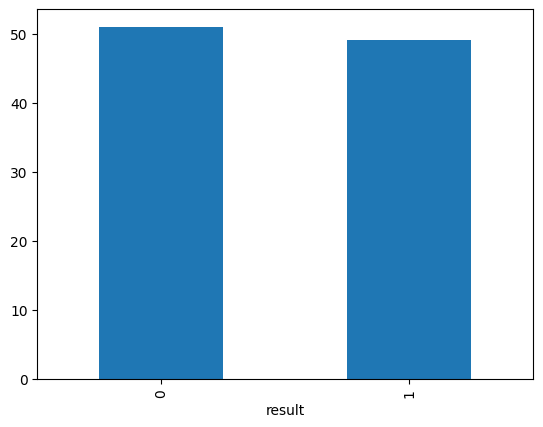

In [ ]:
import seaborn  as sns
# import matplotlib.pyplot as pt

# sns.countplot(delivery['result'])

(delivery['result'].value_counts(normalize=True)*100).plot.bar()

In [ ]:
final_df = delivery[['batting_team','bowling_team','city','runs_required',
                        'balls_left','wickets_left','total_runs_x','curr_run_rate',
                        'req_run_rate','result']]




In [ ]:
final_df.shape

final_df.isnull().sum()

,0
batting_team,0
bowling_team,0
city,1700
runs_required,0
balls_left,0
wickets_left,0
total_runs_x,0
curr_run_rate,0
req_run_rate,5
result,0


In [ ]:
final_df.dropna(inplace=True)

/tmp/ipykernel_16151/2709626079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.dropna(inplace=True)


In [ ]:
final_df.shape

(140378, 10)

In [ ]:

'''
removing row

1. bool masking
2. drop((dat['age'] > 18).index)
3. df.query(df['age'] > 18)
4. df = df[~df.isin(['csk','rcb'])]



'''

"\nremoving row\n\n1. bool masking\n2. drop((dat['age'] > 18).index)\n3. df.query(df['age'] > 18)\n4. df = df[~df.isin(['csk','rcb'])]\n\n\n\n"

In [ ]:

# final_df = final_df[final_df['balls_left'] > 0 ]
# final_df = final_df[final_df['runs_required'] > 0 ]
# final_df = final_df[final_df['wickets_left'] > 0 ]

final_df = final_df.query('runs_required > 0 ')
final_df = final_df.query('wickets_left > 0 ')
final_df = final_df.query('balls_left > 0 ')


final_df.tail()

,batting_team,bowling_team,city,runs_required,balls_left,wickets_left,total_runs_x,curr_run_rate,req_run_rate,result
142012,Chennai Super Kings,Mumbai Indians,Hyderabad,82,68,1,153,8.192308,7.235294,0
142013,Chennai Super Kings,Mumbai Indians,Hyderabad,80,67,1,153,8.264151,7.164179,0
142014,Chennai Super Kings,Mumbai Indians,Hyderabad,80,66,1,153,8.111111,7.272727,0
142015,Chennai Super Kings,Mumbai Indians,Hyderabad,80,65,1,153,7.963636,7.384615,0
142016,Chennai Super Kings,Mumbai Indians,Hyderabad,80,65,1,153,7.963636,7.384615,0


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114612 entries, 0 to 142016
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   batting_team   114612 non-null  object 
 1   bowling_team   114612 non-null  object 
 2   city           114612 non-null  object 
 3   runs_required  114612 non-null  int64  
 4   balls_left     114612 non-null  int64  
 5   wickets_left   114612 non-null  int64  
 6   total_runs_x   114612 non-null  int64  
 7   curr_run_rate  114612 non-null  float64
 8   req_run_rate   114612 non-null  float64
 9   result         114612 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 9.6+ MB


In [ ]:
final_df['bowling_team'] = final_df['bowling_team'].astype('category')
final_df['batting_team'] = final_df['batting_team'].astype('category')
final_df['city'] = final_df['city'].astype('category')

final_df['city'].cat.categories


Index(['Abu Dhabi', 'Ahmedabad', 'Bangalore', 'Bengaluru', 'Bloemfontein',
       'Cape Town', 'Centurion', 'Chandigarh', 'Chennai', 'Cuttack', 'Delhi',
       'Dharamsala', 'Durban', 'East London', 'Hyderabad', 'Indore', 'Jaipur',
       'Johannesburg', 'Kimberley', 'Kolkata', 'Mohali', 'Mumbai', 'Nagpur',
       'Port Elizabeth', 'Pune', 'Raipur', 'Ranchi', 'Sharjah',
       'Visakhapatnam'],
      dtype='object')

In [ ]:
final_df.shape

(114612, 10)

In [ ]:

# Splitting Data into Train and Test Sets

from sklearn.model_selection import train_test_split

data = final_df.copy()

test = data.result

data.drop('result',axis=1)


xtrain,xtest,ytrain,ytest = train_test_split(data,test,test_size=0.3,random_state=42)




In [ ]:
'''

1. get_dummies(df,drop_first=True) - it drops one column
2. change the dtype to category - Kaggle trick
3. OneHotEncoding & StandardScalr(age, salary)



from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

encoded = encoder.fit_transform(df['feature'])

print(encoded.toarray())

print(encoded.get_features_name_out())

or

encoder = OneHotEncoder(sparse='False')

encoded = encoder.fit_transform(df[feat])

df = pd.DF(encoded,columns=encoded.get_feature_names_out())


Learning Notes:

#  ('cat_transformer', OneHotEncoder(sparse_output=False,drop='first'),['batting_team','city','bowling_team'])
# ('std_transformer',StandardScaler(),[])

# print(ct.get_feature_names_out())

# print(trans.get_feature_names_out()) -> this is what I did

# TypeError: 'OneHotEncoder' object is not iterable - I didn't add []
# AttributeError: 'numpy.ndarray' object has no attribute 'get_feature_names_out' - > it belongs to ColumnTransformer and OneHotEncoder

# ct.get_feature_names_out() - At first it asks fit



'''

"\n\n1. get_dummies(df,drop_first=True) - it drops one column\n2. change the dtype to category - Kaggle trick\n3. OneHotEncoding & StandardScalr(age, salary) \n\n\n\nfrom sklearn.preprocessing import OneHotEncoder\n\nencoder = OneHotEncoder()\n\nencoded = encoder.fit_transform(df['feature'])\n\nprint(encoded.toarray())\n\nprint(encoded.get_features_name_out())\n\nor\n\nencoder = OneHotEncoder(sparse='False')\n\nencoded = encoder.fit_transform(df[feat])\n\ndf = pd.DF(encoded,columns=encoded.get_feature_names_out())\n\n\nLearning Notes: \n\n#  ('cat_transformer', OneHotEncoder(sparse_output=False,drop='first'),['batting_team','city','bowling_team'])\n# ('std_transformer',StandardScaler(),[])\n\n# print(ct.get_feature_names_out())\n\n# print(trans.get_feature_names_out()) -> this is what I did\n\n# TypeError: 'OneHotEncoder' object is not iterable - I didn't add []\n# AttributeError: 'numpy.ndarray' object has no attribute 'get_feature_names_out' - > it belongs to ColumnTransformer and On

In [ ]:
data.columns

Index(['batting_team', 'bowling_team', 'city', 'runs_required', 'balls_left',
       'wickets_left', 'total_runs_x', 'curr_run_rate', 'req_run_rate',
       'result'],
      dtype='object')

In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import ( OneHotEncoder, StandardScaler)
from sklearn.linear_model import LogisticRegression



cf = ColumnTransformer(transformers=
    [('tnf1', OneHotEncoder(sparse_output=False,drop='first'),['batting_team','city','bowling_team'])] ,remainder ='passthrough')


trans = ct.fit_transform(data)


cat_features = pd.DataFrame(trans, columns=ct.get_feature_names_out())

cat_features.columns

Index(['tnf1__batting_team_Deccan Chargers',
       'tnf1__batting_team_Delhi Capitals',
       'tnf1__batting_team_Delhi Daredevils',
       'tnf1__batting_team_Kings XI Punjab',
       'tnf1__batting_team_Kolkata Knight Riders',
       'tnf1__batting_team_Mumbai Indians',
       'tnf1__batting_team_Rajasthan Royals',
       'tnf1__batting_team_Royal Challengers Bangalore',
       'tnf1__batting_team_Sunrisers Hyderabad', 'tnf1__city_Ahmedabad',
       'tnf1__city_Bangalore', 'tnf1__city_Bengaluru',
       'tnf1__city_Bloemfontein', 'tnf1__city_Cape Town',
       'tnf1__city_Centurion', 'tnf1__city_Chandigarh', 'tnf1__city_Chennai',
       'tnf1__city_Cuttack', 'tnf1__city_Delhi', 'tnf1__city_Dharamsala',
       'tnf1__city_Durban', 'tnf1__city_East London', 'tnf1__city_Hyderabad',
       'tnf1__city_Indore', 'tnf1__city_Jaipur', 'tnf1__city_Johannesburg',
       'tnf1__city_Kimberley', 'tnf1__city_Kolkata', 'tnf1__city_Mohali',
       'tnf1__city_Mumbai', 'tnf1__city_Nagpur', 'tnf1__

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


pipe1 = Pipeline(steps=[
    ('step1' , cf),
    ('step2' , LogisticRegression(solver='liblinear'))
]

)




In [ ]:
pipe.fit(xtrain,ytrain)
ypred = pipe.predict(xtest)

score = accuracy_score(ytest,ypred)

pipe.predict_proba(xtest)[10]

array([3.98729565e-04, 9.99601270e-01])

In [ ]:
from sklearn.ensemble import RandomForestClassifier


pipe2 = Pipeline(
    steps=[
        ('step1',cf),
        ('step2',RandomForestClassifier())
    ]
)

pipe2.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tnf1',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team', 'city',
                                                   'bowling_team'])])),
                ('step2', RandomForestClassifier())])

In [ ]:
ytest

,result
37790,0
122339,0
118535,1
82656,0
113174,0
...,...
116361,0
95319,0
22609,0
138086,1


In [ ]:
ypred = pipe2.predict(xtest)

score = accuracy_score(ytest,ypred)

score

1.0